# Bifurcations and Breakpoints

Let us consider a population of fish that grows logistically and is being harvested. We can construct the differential equation by combining the logistic growth rate with its harvesting rate. The logistic growth rate is given by:

$$
L = r N \left(1 - \frac{N}{K}\right) \tag{4.1}
$$

where $r$ is the intrinsic per-capita growth rate, $N$ is the population and $K$ is the carrying capacity.

Let us now consider harvesting. Let $H$ be the harvesting rate and $E$ the fishing effort. We assume that the catch of fish per unit effort, $\frac{H}{E}$, is proportional to the stock level $N$:

$$
\frac{H}{E} \propto N  \Rightarrow   \frac{H}{E} = qN  \Rightarrow H = qEN     \tag{4.2}
$$

where $q$ is a catchability constant. We also call $qE$ the fishing mortality. Harvesting decreases the population, so it is subtracted from the logistic growth rate. Combining $(4.1)$ and $(4.2)$ gives us the population's rate of change:

$$
\frac{dN}{dt} = L - H = r N \left(1 - \frac{N}{K}\right) - qEN \tag{4.3}
$$

We now find the equilibria, we set $(4.3)$ equal to zero. We notice that $N^*$ is an equilibrium when the growth rate of the fish population is equal to the harvesting rate:

$$
r N^* \left(1 - \frac{N^*}{K}\right) = qEN^* \tag{4.4}
$$

We have two equilibria,

$$ 
N^*_1 = 0 \tag{4.5a}
$$

and,

$$
N^*_2 = K\left(1 - \frac{qE}{r} \right) \tag{4.5b}
$$

I will plot the figure 2.1 shown in Kot's book:

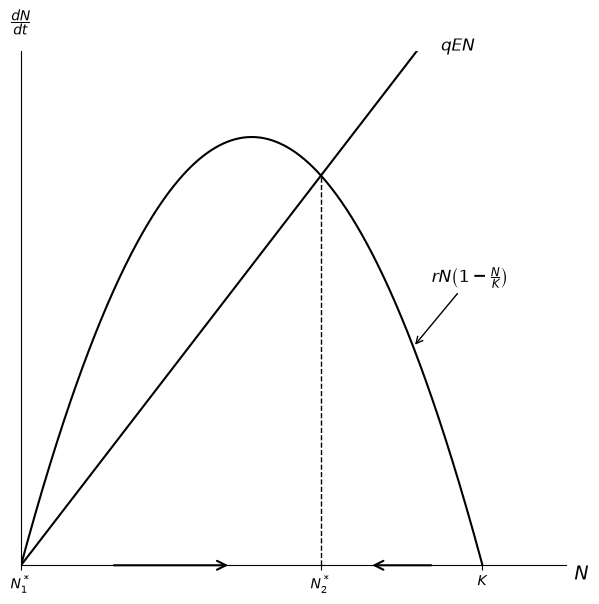

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


r = 1
K = 10
qE = 0.35

N_star = K * (1 - qE / r)
N = np.linspace(0, K + 1, 500)

growth = r * N * (1 - N / K)
harvest = qE * N

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(N, growth, color="black", lw=1.5)
ax.plot(N, harvest, color="black", lw=1.5)
ax.plot([N_star, N_star], [0, qE * N_star], "k--", lw=1)

# Direction arrows directly on the N axis.
ax.add_patch(FancyArrowPatch(
    (0.3 * N_star, 0), (0.7 * N_star, 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))
ax.add_patch(FancyArrowPatch(
    (N_star + 0.7 * (K - N_star), 0),
    (N_star + 0.3 * (K - N_star), 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))

# Label arrows point to the two plotted rates.
ax.annotate(
    r"$qEN$", xy=(8, qE * 8), xytext=(9.1, 3), fontsize=12
)
ax.annotate(
    r"$rN\left(1-\frac{N}{K}\right)$",
    xy=(8.5, r * 8.5 * (1 - 8.5 / K)),
    xytext=(8.9, 1.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12
)

ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, K + 1.8)
ax.set_ylim(0, 3)
ax.set_xticks([N_star, K, 0], [r"$N^*_2$", r"$K$", r"$N^*_1$"])
ax.set_yticks([])
ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.03, 0)
ax.set_ylabel(r"$\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.03)

plt.tight_layout()
plt.show()

The equilibria are given by the intersection of $K\left(1 - \frac{qE}{r} \right)$ and $qEN$.

The equilibrium $N^*_1$ corresponds to extirpation of the stock (local extinction), which is unstable. Any perturbation moves away from this point.

Now, for small values of the fishing mortality, $qE$, the slope of $qEN$ will be shallow, and will intersect with $K\left(1 - \frac{qE}{r} \right)$, creating an equilibrium that is asymptotically stable. Small perturbations to the right of this point, the harvest rate will be greater than the growth rate of prey, meaning the stock level will decrease due to a decrease in prey numbers. A small perturbation means that the growth rate of prey exceed the harvest rate, meaning stock will increase. In both instances, the small perturbations decay and stock level returns to $N^*_1$. As we begin to increase the fishing mortality, the equilibrium for the stock level decreases, but the stability of the equilibrium remains stable. This can be shown in the plot below:

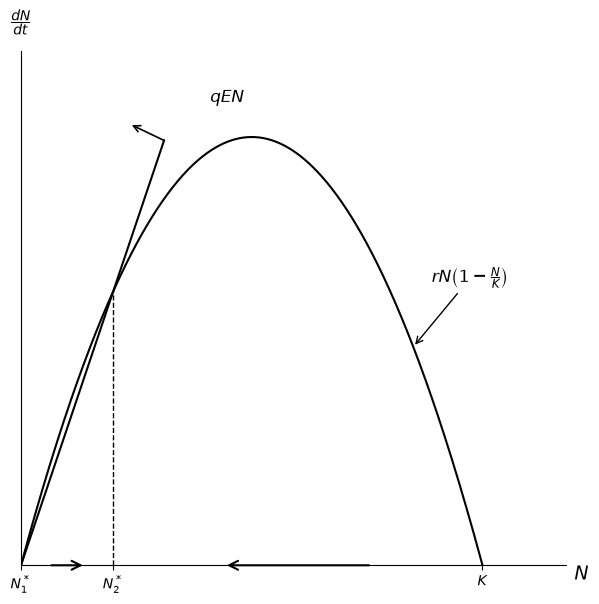

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


r = 1
K = 10
qE = 0.8

N_star = K * (1 - qE / r)
N = np.linspace(0, K + 1, 500)
N_harvest = np.linspace(0, 3.1, 200)



growth = r * N * (1 - N / K)
harvest = qE * N

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(N, growth, color="black", lw=1.5)
ax.plot(N_harvest, qE * N_harvest, color="black", lw=1.5)
ax.plot([N_star, N_star], [0, qE * N_star], "k--", lw=1)

# Direction arrows directly on the N axis.
ax.add_patch(FancyArrowPatch(
    (0.3 * N_star, 0), (0.7 * N_star, 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))
ax.add_patch(FancyArrowPatch(
    (N_star + 0.7 * (K - N_star), 0),
    (N_star + 0.3 * (K - N_star), 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))

# Label arrows point to the two plotted rates.
ax.text(4.1, 2.7, r"$qEN$", fontsize=12)

ax.annotate(
    r"$rN\left(1-\frac{N}{K}\right)$",
    xy=(8.5, r * 8.5 * (1 - 8.5 / K)),
    xytext=(8.9, 1.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12
)

ax.add_patch(FancyArrowPatch(
    (3.1, qE * 3.1),   # starts exactly at the top of the line
    (2.4, 2.57),      # points up and left
    arrowstyle="->",
    mutation_scale=12,
    lw=1.2,
    color="black",
    shrinkA=0,
    shrinkB=0
))

ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, K + 1.8)
ax.set_ylim(0, 3)
ax.set_xticks([N_star, K, 0], [r"$N^*_2$", r"$K$", r"$N^*_1$"])
ax.set_yticks([])
ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.03, 0)
ax.set_ylabel(r"$\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.03)

plt.tight_layout()
plt.show()

We can see how $N^*_2$ has moved to the left. What happens if we keep increasing the fishing mortality? The slop of $qEN$ will increase, making this line steeper, and eventually there is a point at which the line has no non-zero intersection with $rN\left(1 - \frac{N}{K}\right)$. Thus there will be no stable equilibria, since $N^*_2$ relies entirely on the non-zero intersection between $qEN$ and $rN\left(1 - \frac{N}{K}\right)$. $N^*_0$ will the flip and become a stable equilibrium point, meaning that for any stock level, $N \to 0$. Here we can see that the fishing rate exceeds growth rate. Let us plot this:

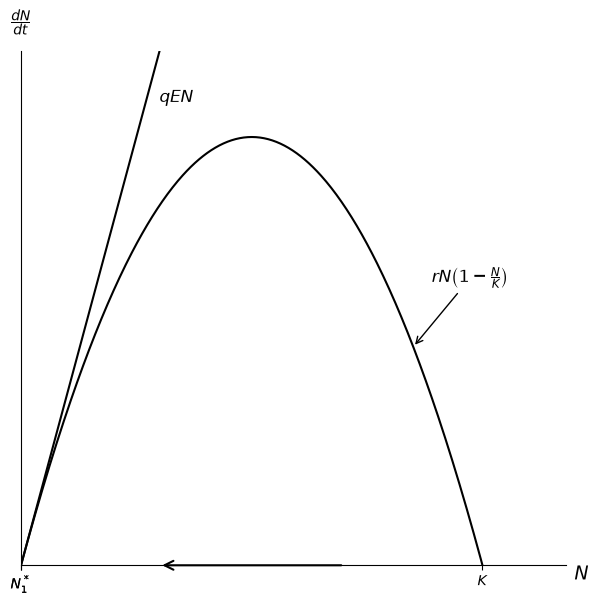

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


r = 1
K = 10
qE = 1

N_star = K * (1 - qE / r)
N = np.linspace(0, K + 1, 500)
N_harvest = np.linspace(0, 3.1, 200)



growth = r * N * (1 - N / K)
harvest = qE * N

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(N, growth, color="black", lw=1.5)
ax.plot(N_harvest, qE * N_harvest, color="black", lw=1.5)
ax.plot([N_star, N_star], [0, qE * N_star], "k--", lw=1)

# Direction arrows directly on the N axis.
ax.add_patch(FancyArrowPatch(
    (0.3 * N_star, 0), (0.7 * N_star, 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))
ax.add_patch(FancyArrowPatch(
    (N_star + 0.7 * (K - N_star), 0),
    (N_star + 0.3 * (K - N_star), 0),
    arrowstyle="->", mutation_scale=16, lw=1.5,
    color="black", zorder=5, clip_on=False
))

# Label arrows point to the two plotted rates.
ax.text(3, 2.7, r"$qEN$", fontsize=12)

ax.annotate(
    r"$rN\left(1-\frac{N}{K}\right)$",
    xy=(8.5, r * 8.5 * (1 - 8.5 / K)),
    xytext=(8.9, 1.65),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12
)


ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, K + 1.8)
ax.set_ylim(0, 3)
ax.set_xticks([N_star, K, 0], [r"$N^*_2$", r"$K$", r"$N^*_1$"])
ax.set_yticks([])
ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.03, 0)
ax.set_ylabel(r"$\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.03)

plt.tight_layout()
plt.show()

The plot illustrates my reasoning above, it shows that extinction equilibrium $N^*_0$ is the only stable one. I will now plot the equilibria as a function of the fishing mortality:

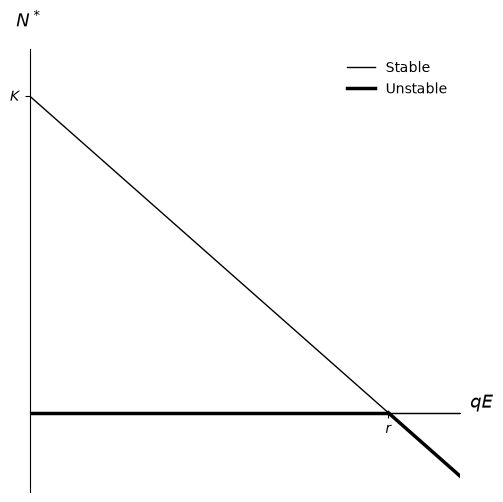

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

r = 1
K = 10

mortality_before = np.linspace(0, r, 200)
mortality_after = np.linspace(r, 1.2 * r, 80)

fig, ax = plt.subplots(figsize=(6, 6))

# Positive equilibrium: stable before qE = r, unstable after.
ax.plot(mortality_before, K * (1 - mortality_before / r),
        color="black", lw=1)
ax.plot(mortality_after, K * (1 - mortality_after / r),
        color="black", lw=2.5)

# Extinction equilibrium: unstable before qE = r, stable after.
ax.plot(mortality_before, np.zeros_like(mortality_before),
        color="black", lw=2.5)
ax.plot(mortality_after, np.zeros_like(mortality_after),
        color="black", lw=1)

ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlim(0, 1.2 * r)
ax.set_ylim(-2.5, 11.5)
ax.set_xticks([r], [r"$r$"])
ax.set_yticks([K], [r"$K$"])

ax.set_xlabel(r"$qE$", fontsize=13)
ax.xaxis.set_label_coords(1.05, 0.22)
ax.set_ylabel(r"$N^*$", rotation=0, fontsize=13)
ax.yaxis.set_label_coords(0, 1.04)

legend_lines = [
    Line2D([0], [0], color="black", lw=1, label="Stable"),
    Line2D([0], [0], color="black", lw=2.5, label="Unstable")
]
ax.legend(handles=legend_lines, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

This plot shows us the stable and unstable branches of the system. The $N^*_2$ equilibrium extends into the fourth quadrant, this is ecologically impossible since $N>0$, but it makes sense mathematically. Branching diagrams, such as the one above, illustrate the location of stability of solutions which are dependent on a parameter are called bifurcation diagrams. In the bifurcation diagram above, we see a transcritical bifurcation at $qE = r$, the two branches 'collide' and exchange stability. At this bifurcation, there is a qualitative change in the behaviour of the system. 

The equilibrial harvest rate or sustainable yield is equally important. The sustainable yield rate at the equilibrium $(4.5b)$ is given by:

$$ 
Y = qEN^*_1 = qEK\left(1 - \frac{qE}{r}\right) \tag{4.6}
$$

The graph of this function is a parabola when plotting $Y$ as a function of fishing mortality $qE$:

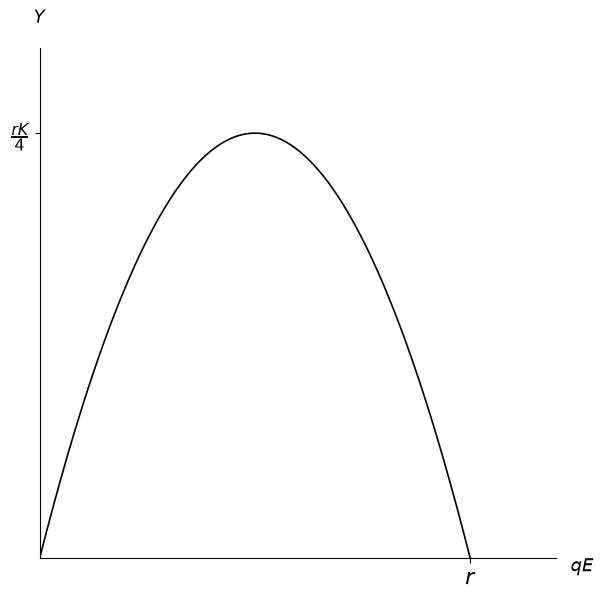

In [54]:
import numpy as np
import matplotlib.pyplot as plt

r = 1
K = 10

qE = np.linspace(0, r, 500)
Y = qE * K * (1 - qE / r)
Y_max = r * K / 4

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(qE, Y, color="black", lw=1.2)

ax.set_xlim(0, 1.2 * r)
ax.set_ylim(0, 1.2 * Y_max)
ax.set_xticks([r], [r"$r$"], fontsize=16)
ax.set_yticks([Y_max], [r"$\frac{rK}{4}$"], fontsize=16)

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$qE$", fontsize=13)
ax.xaxis.set_label_coords(1.05, 0)
ax.set_ylabel(r"$Y$", rotation=0, fontsize=13)
ax.yaxis.set_label_coords(0, 1.04)

plt.tight_layout()
plt.show()

As we increase fishing effort, $E$, the sustainable yield increases, up until a point ($\frac{r}{2}$ in our example). Further increasing the effort will lead to a decrease in yield as the stock becomes increasingly overexploited and depleted. For a fixed catchability, $q$, the maximum sustainable yield (MSY) happens when:

$$
\frac{dY}{dE} = qK \left(1 - \frac{2qE}{r} \right) = 0 \tag{4.5}
$$

The corresponding optimal level of effort is:

$$
E_{MSY} = \frac{r}{2q} \tag{4.6}
$$

Which produces a the maximum sustainable yield:

$$
MSY = \frac{rK}{4} \tag{4.7}
$$

So far, using the fish harvesting model, we have assumed that fish populations grow logistically. Some populations possess a threshold to growth, which means that population must start above a critical size, denoted $K_0$, for its rate of growth to be positive. For example, if there were only one rabbit, it would not have anything to breed with, once that one rabbit dies, this population will be extinct. Generally, when a population is small, the individuals may find it hard to find a mate.

Now, let us consider a different simple differential equation:

$$
\frac{dN}{dt}=rN\left(\frac{N}{K_0}-1\right)\left(1-\frac{N}{K}\right) \tag{4.8}
$$

Let us plot $\frac{dN}{dt}$ as a function of $N$:

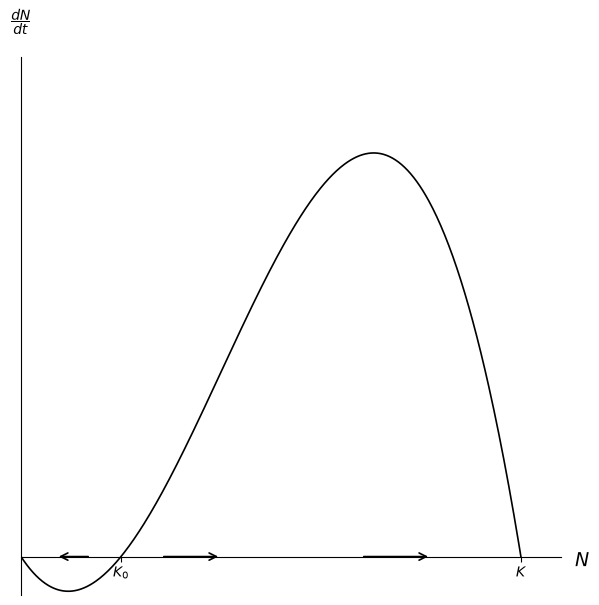

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

r = 1
K_0 = 2
K = 10

N = np.linspace(0, K, 500)
dN_dt = r * N * (N / K_0 - 1) * (1 - N / K)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(N, dN_dt, color="black", lw=1.2)

# Direction of population change along the N axis.
for start, end in [(1.4, 0.7), (2.8, 4.0), (6.8, 8.2)]:
    ax.add_patch(FancyArrowPatch(
        (start, 0), (end, 0),
        arrowstyle="->",
        mutation_scale=13,
        lw=1.2,
        color="black",
        zorder=5,
    ))

ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlim(0, 10.8)
ax.set_ylim(-0.5, 6.5)
ax.set_xticks([K_0, K], [r"$K_0$", r"$K$"])
ax.set_yticks([])

ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.04, 0.08)
ax.set_ylabel(r"$\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.04)

plt.tight_layout()
plt.show()

We can see that for $N$ below the threshold, $K_0$, $\frac{dN}{dt}$ is negative for these values, meaning that for $N<K_0$, $N \to 0$ as time increases, this model exhibits critical dispensation. For initial conditions where $N_0 > K_0$, $N \to K$ as t increases. Since this model experiences negative growth rate at low population rates, we say this model exhibits critical depensation. Also, the per capita growth rate is no longer a monotonically decreasing function of density but instead shows an Allee effect, or an increase in the per capita growth rate, over certain ranges of density, which can be shown in the plot below:

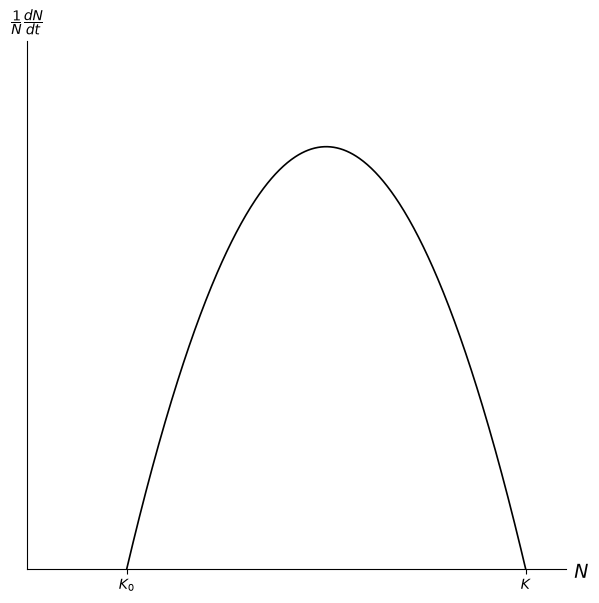

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

r = 1
K_0 = 2
K = 10

N = np.linspace(K_0, K, 500)
dN_dt = r  * (N / K_0 - 1) * (1 - N / K)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(N, dN_dt, color="black", lw=1.2)


ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlim(0, 10.8)
ax.set_ylim(-0, 1)
ax.set_xticks([K_0, K], [r"$K_0$", r"$K$"])
ax.set_yticks([])

ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.03, 0.01)
ax.set_ylabel(r"$\frac{1}{N}\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.01)

plt.tight_layout()
plt.show()

After some quick calculations, for $N>0$ we can identify the point given at $N= \left(\frac{K_0 + K}{2}\right)$ is the maximum per capita growth rate.

We shall now add harvesting to the model given in $(4.8)$. Harvesting will decrease the rate of growth, so we add $-qEN$:

$$
\frac{dN}{dt}=rN\left(\frac{N}{K_0}-1\right)\left(1-\frac{N}{K}\right) - qEN \tag{4.9}
$$

Lets plot a graph to see when equilibria will occur:

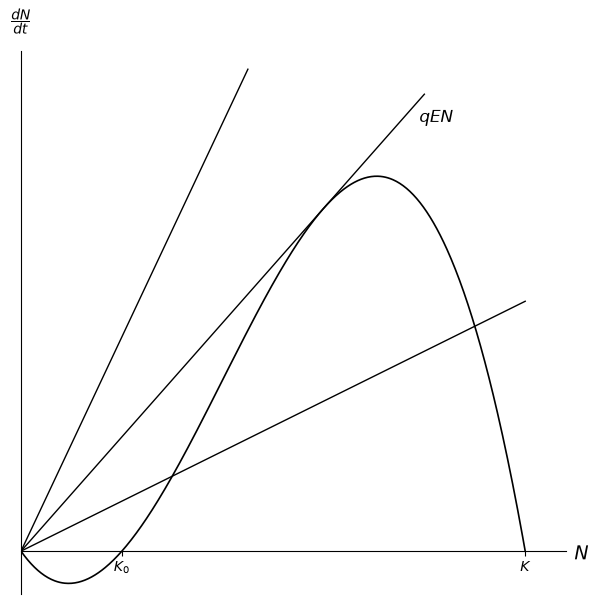

In [17]:
import numpy as np
import matplotlib.pyplot as plt

r = 1
K_0 = 2
K = 10

N = np.linspace(0, K, 600)
growth = r * N * (N / K_0 - 1) * (1 - N / K)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(N, growth, color="black", lw=1.2)

# Three fishing mortalities: low, tangent, and high.
for qE, end_N in [(0.35, 10), (0.8, 8), (1.5, 4.5)]:
    N_line = np.linspace(0, end_N, 200)
    ax.plot(N_line, qE * N_line, color="black", lw=1)

ax.annotate(
    r"$qEN$",
    xy=(5, 0.8 * 5),
    xytext=(7.9, 6),
    fontsize=12,
)

ax.spines["bottom"].set_position(("data", 0))
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 10.8)
ax.set_ylim(-0.6, 7)
ax.set_xticks([K_0, K], [r"$K_0$", r"$K$"])
ax.set_yticks([])

ax.set_xlabel(r"$N$", fontsize=14)
ax.xaxis.set_label_coords(1.03, 0.09)
ax.set_ylabel(r"$\frac{dN}{dt}$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.03)

plt.tight_layout()
plt.show()

Equilibria occur when

$$
rN^*\left(\frac{N^*}{K_0} - 1 \right)\left(1 - \frac{N^*}{K}\right) = qEN^* \tag{4.10}
$$

Trivially, there is an equilibrium at $N^*=0$. The remaining equilibria are found by solving a 2nd order polynomial:

$$
r\left(\frac{N^*}{K_0} - 1 \right)\left(1 - \frac{N^*}{K}\right) = qE\tag{4.11}
$$

From the graph above, we can see that the number of non-zero equilibria changes with the value for $E$, since $q$ is fixed. We observe that there is a critical value $E_{\mathrm{crit}}$. For $E < E_{\mathrm{crit}}$ we have 2 non-zero equilibria. For $E > E_{\mathrm{crit}}$, we have no non-zero equilibria. The change occurs when the harvesting line $qEN$ is tangent to the population growth curve. At this point, the 2 equilibria meet at $N_{\mathrm{crit}}$ to form one distinct equilibrium, which is found to be:

$$
N_{\mathrm{crit}} = \frac{K_0 + K}{2} \tag{4.12}
$$

Substituting $N_{\mathrm{crit}}$ into $(4.11)$ and solving for $E$ gives the critical value:

$$
E_{\mathrm{crit}}=\frac{r(K-K_0)^2}{4qKK_0}, \qquad q>0. \tag{4.13}
$$

Now, for $N>0$ and $0 \leq E < E_{\mathrm{crit}}$, the 2 distinct equilibria are given by:

$$
N^*_{\pm} = \frac{K+K_0\pm\sqrt{(K-K_0)^2-\frac{4KK_0qE}{r}}}{2} \tag{4.14}
$$

As mentioned, for $E > E_{\mathrm{crit}}$, there are no non-zero equilibria, thus meaning that $N^* = 0$ becomes the only non-negative equilibrium, and positive populations decline to extinction.

We shall now plot the bifurcation diagram for this system:

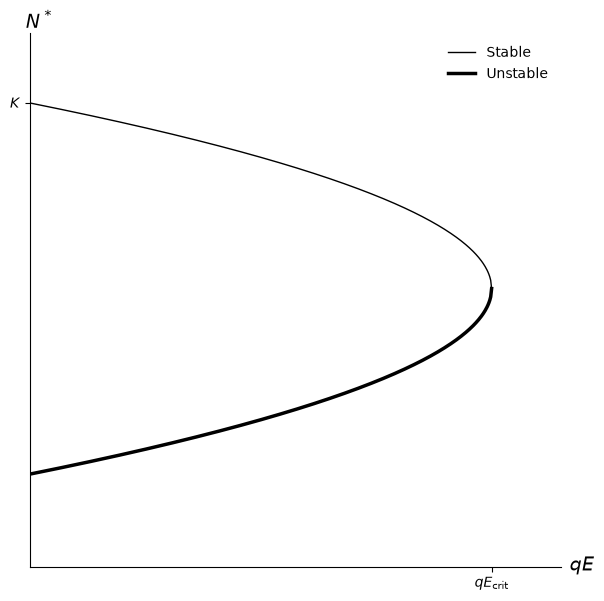

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

r = 1
K_0 = 2
K = 10

qE_crit = r * (K - K_0)**2 / (4 * K * K_0)
qE = np.linspace(0, qE_crit, 500)

discriminant = (K - K_0)**2 - 4 * K * K_0 * qE / r
N_upper = (K + K_0 + np.sqrt(np.maximum(discriminant, 0))) / 2
N_lower = (K + K_0 - np.sqrt(np.maximum(discriminant, 0))) / 2

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(qE, N_upper, color="black", lw=1)    # stable
ax.plot(qE, N_lower, color="black", lw=2.5)  # unstable

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 1.15 * qE_crit)
ax.set_ylim(0, 1.15 * K)
ax.set_xticks([qE_crit], [r"$qE_{\mathrm{crit}}$"])
ax.set_yticks([K], [r"$K$"])

ax.set_xlabel(r"$qE$", fontsize=14)
ax.xaxis.set_label_coords(1.04, 0.02)
ax.set_ylabel(r"$N^*$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0.02, 1.0)

ax.legend(
    handles=[
        Line2D([0], [0], color="black", lw=1, label="Stable"),
        Line2D([0], [0], color="black", lw=2.5, label="Unstable"),
    ],
    frameon=False,
    loc="upper right",
)

plt.tight_layout()
plt.show()

Here, we have plotted $N^*$ as a function of fishing mortality $qE$.

There are 3 branches of equilibria:

1. Lower branch: $N^*=0$, stable (not drawn in this plot)
2. Middle branch: $N^*_-$, unstable
3. Upper branch: $N^*_+$, stable

The middle branch consists of unstable equilibria that act as breakpoints between the two stable branches. As the fishing mortality increases, $qE$, the equilibria on the upper and middle branches approach each other. 

In general, they eventually collide and collide and disappear in a fold, tangent or saddle node bifurcation. In our example above, it is a saddle-node bifurcation.

In this example, a fishery who is close to this bifurcation point may undergo catastrophic collapse after a small increase in fishing mortality. This can be displayed in the yield curve:

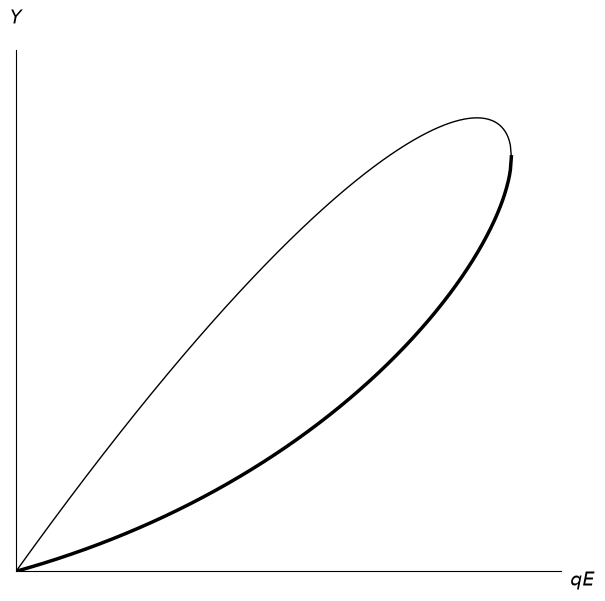

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

r = 1
K_0 = 2
K = 10

qE_crit = r * (K - K_0)**2 / (4 * K * K_0)
qE = np.linspace(0, qE_crit, 500)

discriminant = (K - K_0)**2 - 4 * K * K_0 * qE / r
root = np.sqrt(np.maximum(discriminant, 0))

N_upper = (K + K_0 + root) / 2
N_lower = (K + K_0 - root) / 2

Y_upper = qE * N_upper
Y_lower = qE * N_lower

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(qE, Y_upper, color="black", lw=1, label="Stable")
ax.plot(qE, Y_lower, color="black", lw=2.5, label="Unstable")

ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 1.1 * qE_crit)
ax.set_ylim(0, 1.15 * max(Y_upper))
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel(r"$qE$", fontsize=14)
ax.xaxis.set_label_coords(1.04, 0)
ax.set_ylabel(r"$Y$", rotation=0, fontsize=14)
ax.yaxis.set_label_coords(0, 1.04)

plt.tight_layout()
plt.show()

This yield curve shows a catastrophic collapse at high enough fishing mortality levels. Bifurcations and breakpoints pervade mathematical ecology, small changes often have large effects. 

All the bifurcations we hve explored are of codimension 1. The codimension is the minimum number of co parameters that are needed to characterise the bifurcation. However, not all codimension-1 bifurcations are equally robust. Small perturbations to the structure of the model may effect different bifurcations in different ways.

This poses the need to analyse the structural stability of a bifurcation that arise in in differential equations of the form:

$$
\frac{dN}{dt} = f(N,\mu) \tag{4.15}
$$

where $\mu$ is the bifurcation parameter. We now need to consider the perturbed differential equation:

$$
\frac{dN}{dt} = f(N,\mu) + \epsilon g(N) \tag{4.16}
$$

where $\epsilon$ is the small amplitude of the structural perturbation, and $g(N)$ is some function. We expand $g(N)$ in a Taylor expansion about the bifurcation point and keep only the lower-order terms (we are only concerned with changes close to the bifurcation point). The function $g(N)$ may be thought as an imperfection. We wish to discover if this imperfection causes qualitative changes in the bifurcation diagram. 

Let us go back to our example in $(4.3)$, we can display the structural instability of transcritical bifurcations by adding a small constant:

$$
\frac{dN}{dt} = r N \left(1 - \frac{N}{K}\right) + I - qEN \tag{4.17}
$$

Where $I$ is a migration constant. For $I > 0$, we have immigration. For $I < 0$, we have emigration. I will now plot bifurcation diagrams for small positive, small negative and zero $I$:

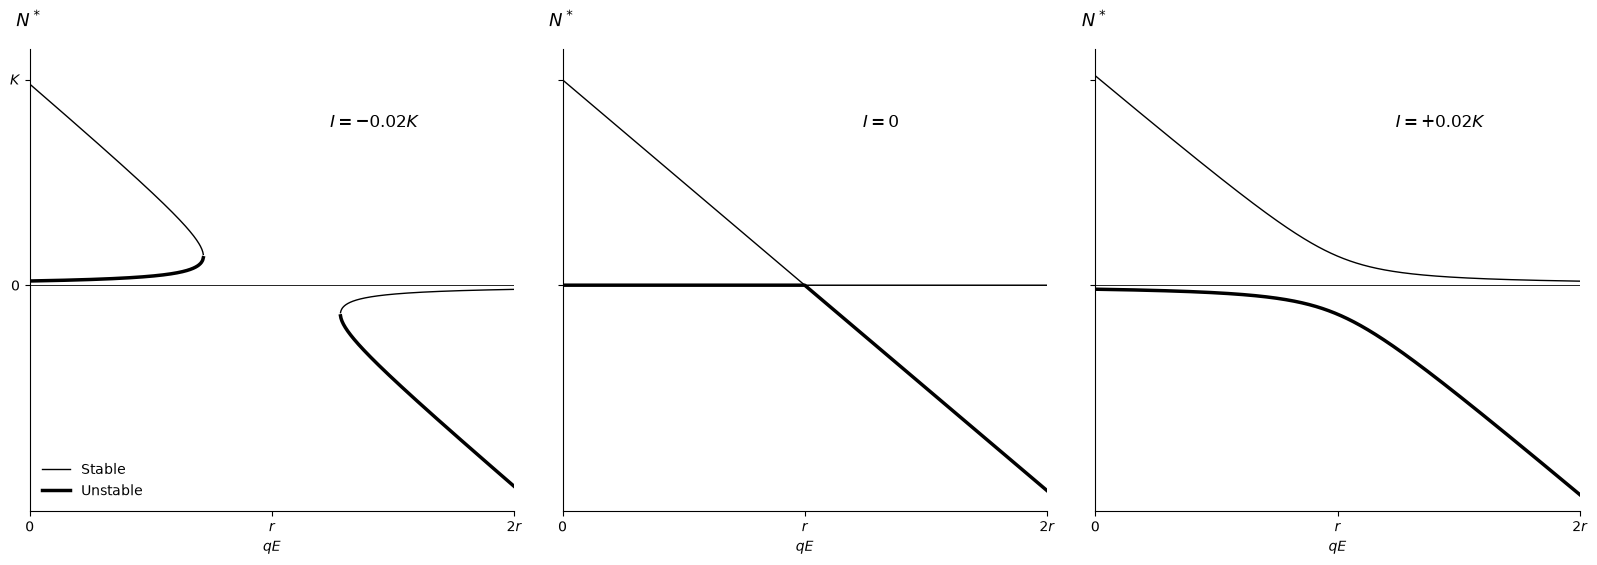

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

r = 1
K = 10
qE = np.linspace(0, 2 * r, 1000)

migration_cases = [
    (-0.02 * K, r"$I=-0.02K$"),
    (0, r"$I=0$"),
    (0.02 * K, r"$I=+0.02K$"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (I, label) in zip(axes, migration_cases):
    discriminant = (r - qE)**2 + 4 * r * I / K
    real_roots = discriminant >= 0
    root = np.sqrt(np.maximum(discriminant, 0))

    N_stable = K * ((r - qE) + root) / (2 * r)
    N_unstable = K * ((r - qE) - root) / (2 * r)

    ax.plot(qE, np.where(real_roots, N_stable, np.nan),
            color="black", lw=1)
    ax.plot(qE, np.where(real_roots, N_unstable, np.nan),
            color="black", lw=2.5)

    ax.axhline(0, color="black", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, 2 * r)
    ax.set_ylim(-1.1 * K, 1.15 * K)
    ax.set_yticks([0, K], ["0", r"$K$"])
    ax.set_xticks([0, r, 2 * r], ["0", r"$r$", r"$2r$"])
    ax.tick_params(labelbottom=True)

    ax.text(0.62, 0.83, label, transform=ax.transAxes, fontsize=12)
    ax.set_ylabel(r"$N^*$", rotation=0, fontsize=13)
    ax.yaxis.set_label_coords(0, 1.04)
    ax.set_xlabel(r"$qE$")

axes[0].legend(
    handles=[
        Line2D([0], [0], color="black", lw=1, label="Stable"),
        Line2D([0], [0], color="black", lw=2.5, label="Unstable"),
    ],
    frameon=False,
    loc="lower left",
)

fig.subplots_adjust(wspace=0.1)
plt.show()

Using the bifurcation diagrams above, we see:

1. For small emigration, the transcritical bifurcation is replaced by two fold bifurcations. Catastrophic collapse happens in the first fold as $qE$ increases along the positive stable branch.
2. For small immigration, there is no bifurcation as there is no definite point where qualitative change can be observed.

In this model, a small migration removes the transcritical bifurcation, showing that this bifurcation structurally unstable.